Перевірка даних після очистки: (17293, 9)


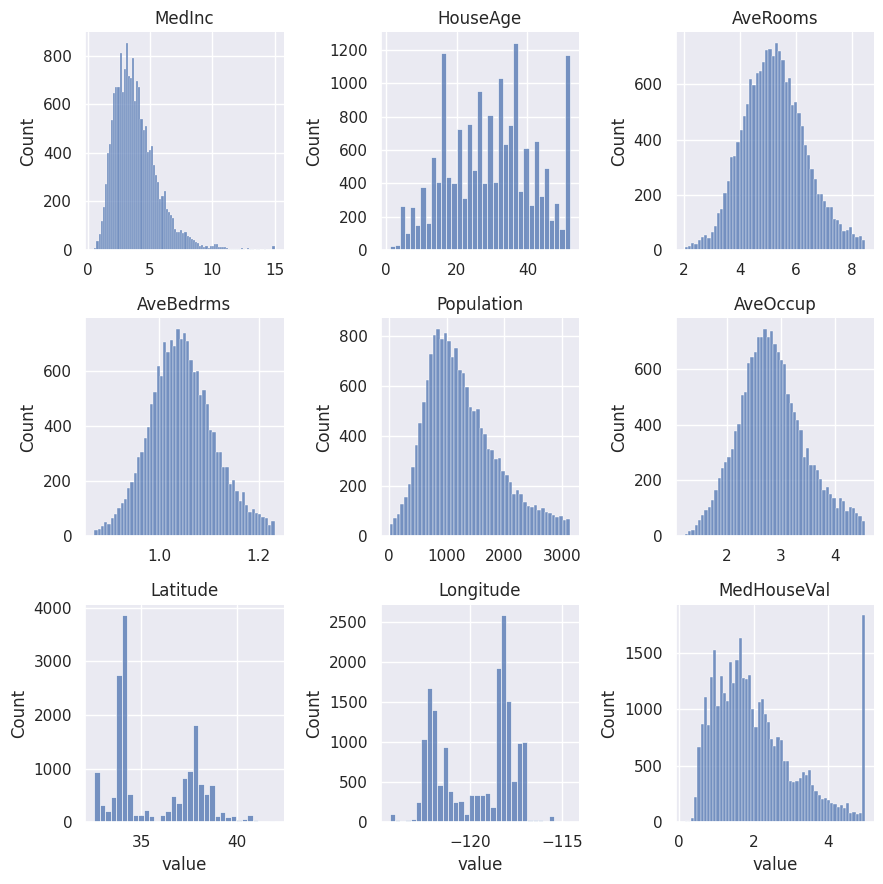

In [5]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
import seaborn as sns
import matplotlib.pyplot as plt

#завантаження набору даних
california_housing = fetch_california_housing(as_frame= True)
data = california_housing['frame']
target = california_housing['target']

#очищення викидів
data = data[(data['AveRooms'] >= data['AveRooms'].quantile(0.25) - 1.5 * (data['AveRooms'].quantile(0.75) - data['AveRooms'].quantile(0.25))) & (data['AveRooms'] <= data['AveRooms'].quantile(0.75) + 1.5 * (data['AveRooms'].quantile(0.75) - data['AveRooms'].quantile(0.25)))]
data = data[(data['AveBedrms'] >= data['AveBedrms'].quantile(0.25) - 1.5 * (data['AveBedrms'].quantile(0.75) - data['AveBedrms'].quantile(0.25))) & (data['AveBedrms'] <= data['AveBedrms'].quantile(0.75) + 1.5 * (data['AveBedrms'].quantile(0.75) - data['AveBedrms'].quantile(0.25)))]
data = data[(data['AveOccup'] >= data['AveOccup'].quantile(0.25) - 1.5 * (data['AveOccup'].quantile(0.75) - data['AveOccup'].quantile(0.25))) & (data['AveOccup'] <= data['AveOccup'].quantile(0.75) + 1.5 * (data['AveOccup'].quantile(0.75) - data['AveOccup'].quantile(0.25)))]
data = data[(data['Population'] >= data['Population'].quantile(0.25) - 1.5 * (data['Population'].quantile(0.75) - data['Population'].quantile(0.25))) & (data['Population'] <= data['Population'].quantile(0.75) + 1.5 * (data['Population'].quantile(0.75) - data['Population'].quantile(0.25)))]

print('Перевірка даних після очистки:', data.shape)

#побудова графіків
sns.set_theme()
melted = pd.concat([data, target], axis=1).melt()
g = sns.FacetGrid(melted, col='variable', col_wrap=3, sharex=False, sharey=False)
g.map(sns.histplot, 'value')
g.set_titles(col_template='{col_name}')
g.tight_layout()


